<a href="https://colab.research.google.com/github/JamesEckhartJr/Quantum-Hardware-Projects/blob/main/da_Vinci_2_Qubit_Bell_%2B_GHZ_State.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


OPENQASM 2.0;

qreg q[1];

creg c[1];

h q[0];

measure q[0] -> c[0];

=== Running da Vinci Quantum Emulator: 2-Qubit Bell State ===
Bell State Results (top 10): {'11': 1035, '00': 1013}


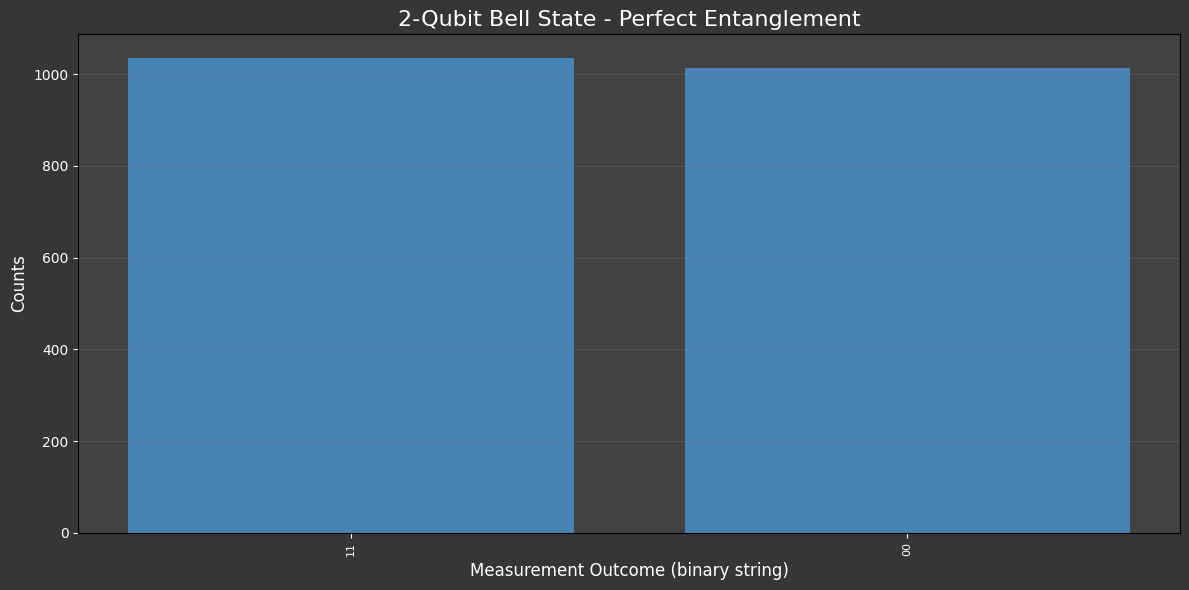

In [27]:
#Start QASM -- text based language. Opens the same on every program.
program = """
OPENQASM 2.0;
"""
program += """
qreg q[1];
"""
program += """
creg c[1];
"""
program += """
h q[0];
"""
program += """
measure q[0] -> c[0];
"""
print(program)

# Ed Dillinger: What's the project you're working on? Alan Bradley: Well, it's called Tron...

#Data handling and communication protocols -- Import JSON for working with
#JavaScript Object Notation and making HTTP requests to 'Quantum Emulator'
import json
import requests
import matplotlib.pyplot as plt
from collections import Counter

#Suppress warnings (optional, but needed for visual output)
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)  # Disable warnings about insecure requests

da_Vinci_Quantum_Emulator = 'theq-ae31b1'

#Quantum Emulator address
QUOKKA_URL = 'http://{}.quokkacomputing.com/qsim/qasm'.format(da_Vinci_Quantum_Emulator)

SHOTS = 2048 # Number of measurement shots

# ================================================================

def run_qasm(qasm_code: str, shots: int = SHOTS):
    """Send OpenQASM 2.0 code to the Quokka Puck and return measurement counts."""
    payload = {
        "script": qasm_code.strip(),
        "count": shots
    }
    try:
        response = requests.post(QUOKKA_URL, json=payload, timeout=600)
        response.raise_for_status()
        raw_results = response.json()
        if raw_results and 'result' in raw_results and 'c' in raw_results['result']:
            # Convert list of lists like [[0, 0], [1, 1]] to a list of strings like ["00", "11"]
            measurement_outcomes = ["".join(map(str, res)) for res in raw_results['result']['c']]
            return Counter(measurement_outcomes) # Return a dictionary of outcome -> count
        else:
            print("Unexpected response format from Quokka Puck:", raw_results)
            return {}
    except Exception as e:
        print(f"Error communicating with Quokka Puck: {e}")
        return {}

def plot_results(results: dict, title: str):
    """Plot measurement histogram."""
    if not results:
        print("No results to plot.")
        return

    counts = Counter(results)
    labels = list(counts.keys())
    values = list(counts.values())

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.set_facecolor('#363636') # Dark background for the entire figure
    ax.set_facecolor('#424242') # Slightly lighter dark background for the plot area

    ax.bar(labels, values, color='steelblue')
    ax.set_title(title, fontsize=16, color='white')
    ax.set_xlabel("Measurement Outcome (binary string)", fontsize=12, color='white')
    ax.set_ylabel("Counts", fontsize=12, color='white')
    ax.tick_params(axis='x', colors='white', rotation=90, labelsize=8)
    ax.tick_params(axis='y', colors='white')
    ax.grid(axis='y', alpha=0.3, color='gray')
    plt.tight_layout()
    plt.show()

    # ========================= BELL STATE =========================
print("=== Running da Vinci Quantum Emulator: 2-Qubit Bell State ===")

bell_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];          // Create superposition
cx q[0], q[1];   // Entangle the two qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

bell_results = run_qasm(bell_qasm, SHOTS)
print("Bell State Results (top 10):", dict(list(bell_results.items())[:10]))

plot_results(bell_results, "2-Qubit Bell State - Perfect Entanglement")

### 3-Qubit GHZ State Circuit

The Greenberger–Horne–Zeilinger (GHZ) state is another example of a multi-qubit entangled state. For three qubits, the ideal GHZ state is (1/√2)(|000⟩ + |111⟩), meaning that if one qubit is measured to be 0, the others will also be 0, and similarly for 1.

=== Running da Vinci Quantum Emulator: 3-Qubit GHZ State ===
GHZ State Results (top 10): {'111': 4181, '000': 4011}


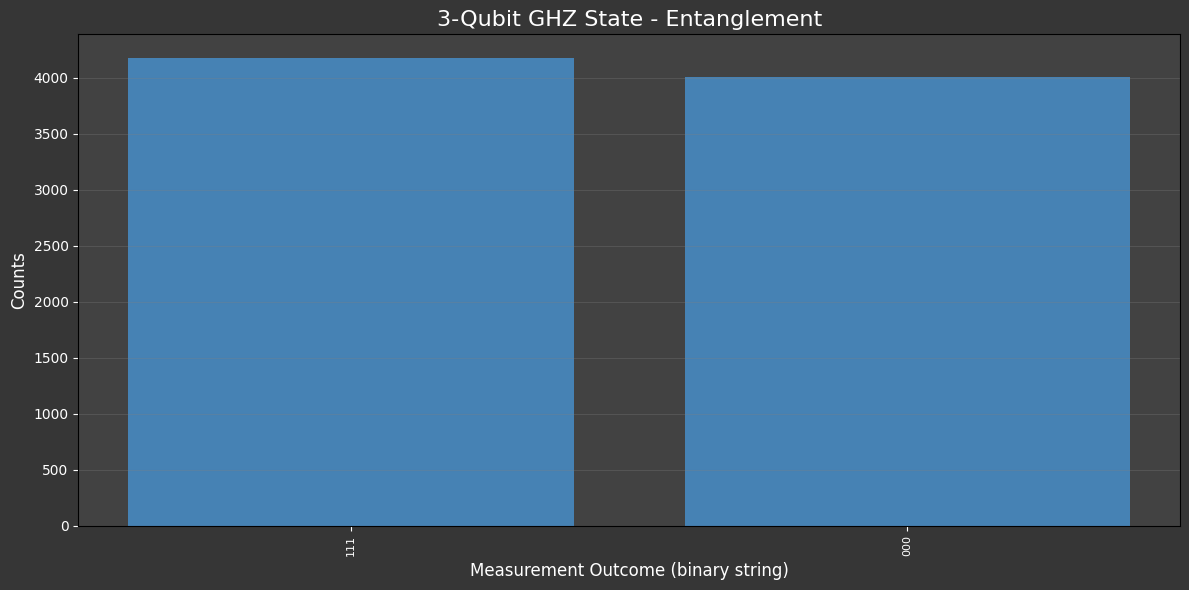

In [ ]:
print("=== Running da Vinci Quantum Emulator: 3-Qubit GHZ State ===")

ghz_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[3];
creg c[3];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
"""

ghz_results = run_qasm(ghz_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz_results.items())[:10]))

plot_results(ghz_results, "3-Qubit GHZ State - Entanglement")

### 4-Qubit GHZ State Circuit

Extending the concept, the ideal 4-qubit GHZ state is (1/√2)(|0000⟩ + |1111⟩), demonstrating entanglement across four qubits.

=== Running da Vinci Quantum Emulator: 4-Qubit GHZ State ===
GHZ State Results (top 10): {'1111': 4157, '0000': 4035}


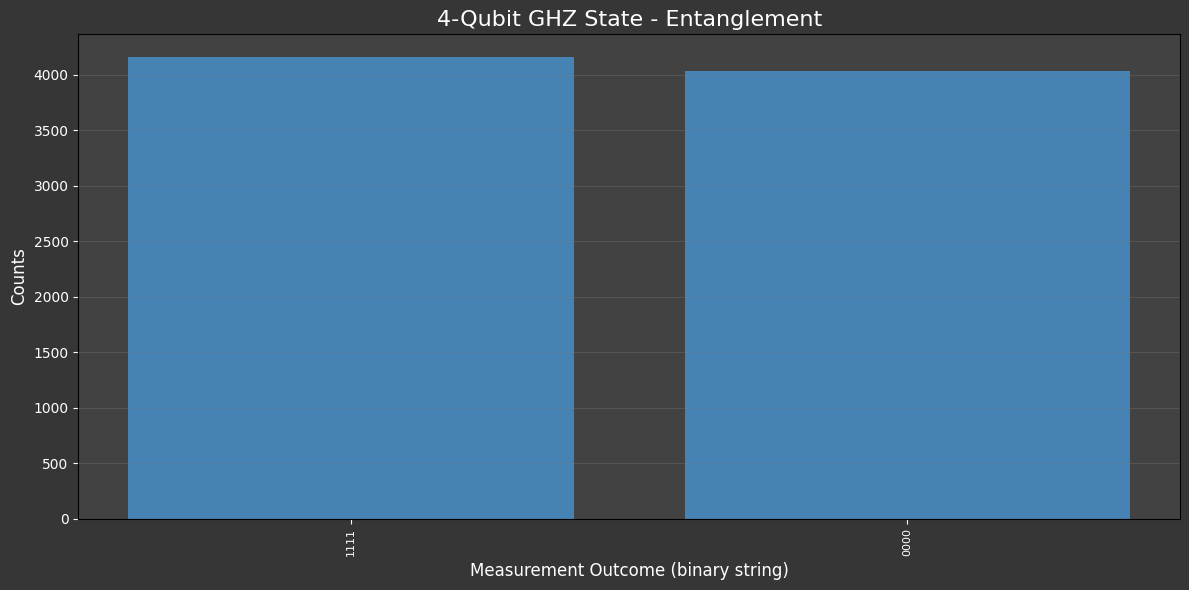

In [ ]:
print("=== Running da Vinci Quantum Emulator: 4-Qubit GHZ State ===")

ghz4_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg c[4];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
"""

ghz4_results = run_qasm(ghz4_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz4_results.items())[:10]))

plot_results(ghz4_results, "4-Qubit GHZ State - Entanglement")

### 5-Qubit GHZ State Circuit

Continuing the pattern, the ideal 5-qubit GHZ state is (1/√2)(|00000⟩ + |11111⟩), demonstrating entanglement across five qubits.

=== Running da Vinci Quantum Emulator: 5-Qubit GHZ State ===
GHZ State Results (top 10): {'00000': 4055, '11111': 4137}


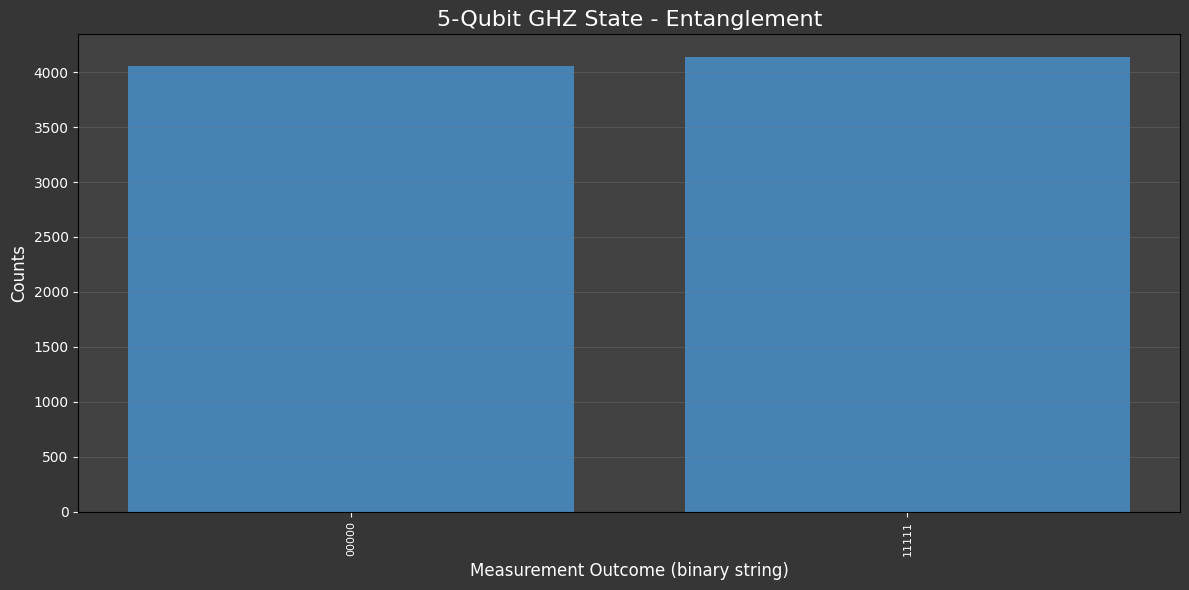

In [ ]:
print("=== Running da Vinci Quantum Emulator: 5-Qubit GHZ State ===")

ghz5_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[5];
creg c[5];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
"""

ghz5_results = run_qasm(ghz5_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz5_results.items())[:10]))

plot_results(ghz5_results, "5-Qubit GHZ State - Entanglement")

### 6-Qubit GHZ State Circuit

Following the established pattern, the ideal 6-qubit GHZ state is (1/√2)(|000000⟩ + |111111⟩), showcasing entanglement across six qubits.

=== Running da Vinci Quantum Emulator: 6-Qubit GHZ State ===
GHZ State Results (top 10): {'000000': 4079, '111111': 4113}


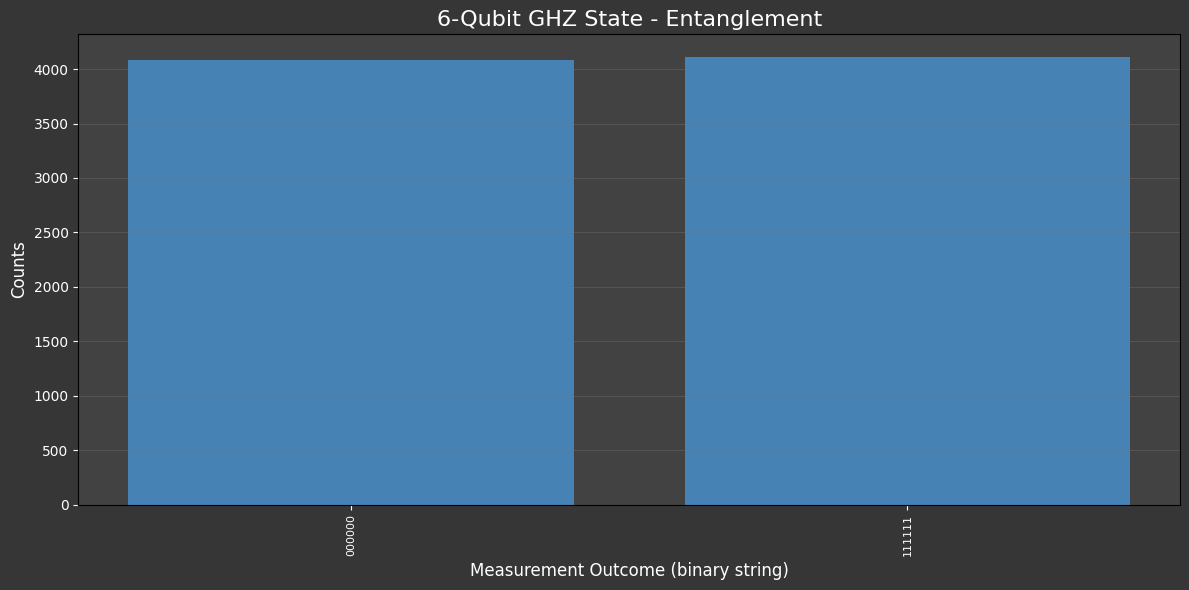

In [ ]:
print("=== Running da Vinci Quantum Emulator: 6-Qubit GHZ State ===")

ghz6_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[6];
creg c[6];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
"""

ghz6_results = run_qasm(ghz6_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz6_results.items())[:10]))

plot_results(ghz6_results, "6-Qubit GHZ State - Entanglement")

### 7-Qubit GHZ State Circuit

Extending to seven qubits, the ideal 7-qubit GHZ state is (1/√2)(|0000000⟩ + |1111111⟩), showcasing entanglement across seven qubits.

=== Running da Vinci Quantum Emulator: 7-Qubit GHZ State ===
GHZ State Results (top 10): {'1111111': 4128, '0000000': 4064}


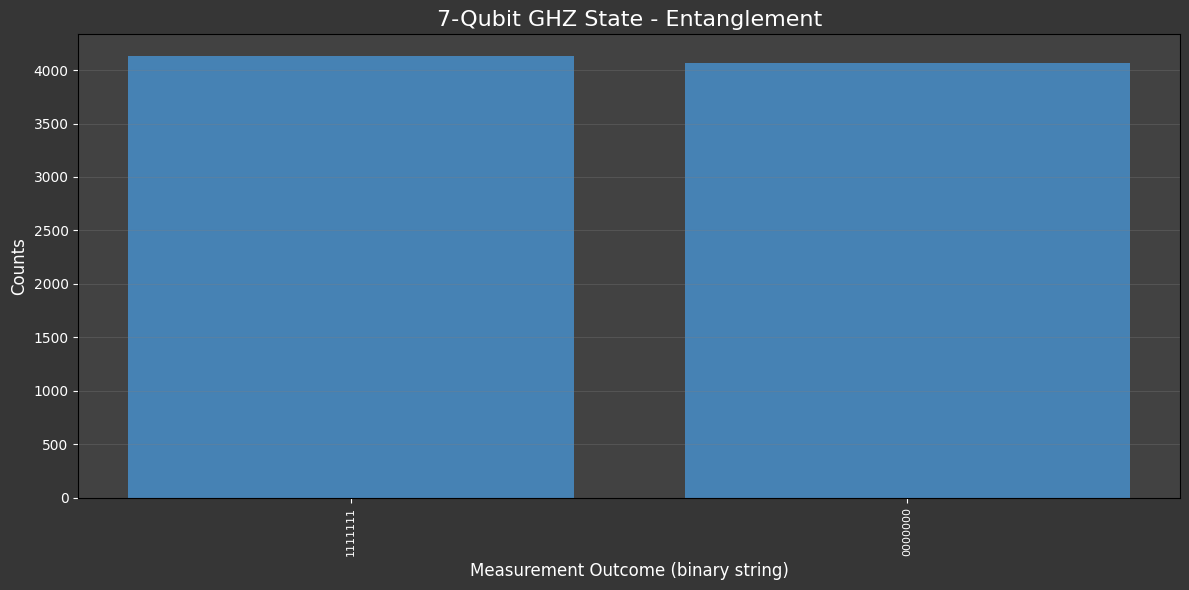

In [ ]:
print("=== Running da Vinci Quantum Emulator: 7-Qubit GHZ State ===")

ghz7_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[7];
creg c[7];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
"""

ghz7_results = run_qasm(ghz7_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz7_results.items())[:10]))

plot_results(ghz7_results, "7-Qubit GHZ State - Entanglement")

### 8-Qubit GHZ State Circuit

Continuing the expansion, the ideal 8-qubit GHZ state is (1/√2)(|00000000⟩ + |11111111⟩), demonstrating entanglement across eight qubits.

=== Running da Vinci Quantum Emulator: 8-Qubit GHZ State ===
GHZ State Results (top 10): {'11111111': 4144, '00000000': 4048}


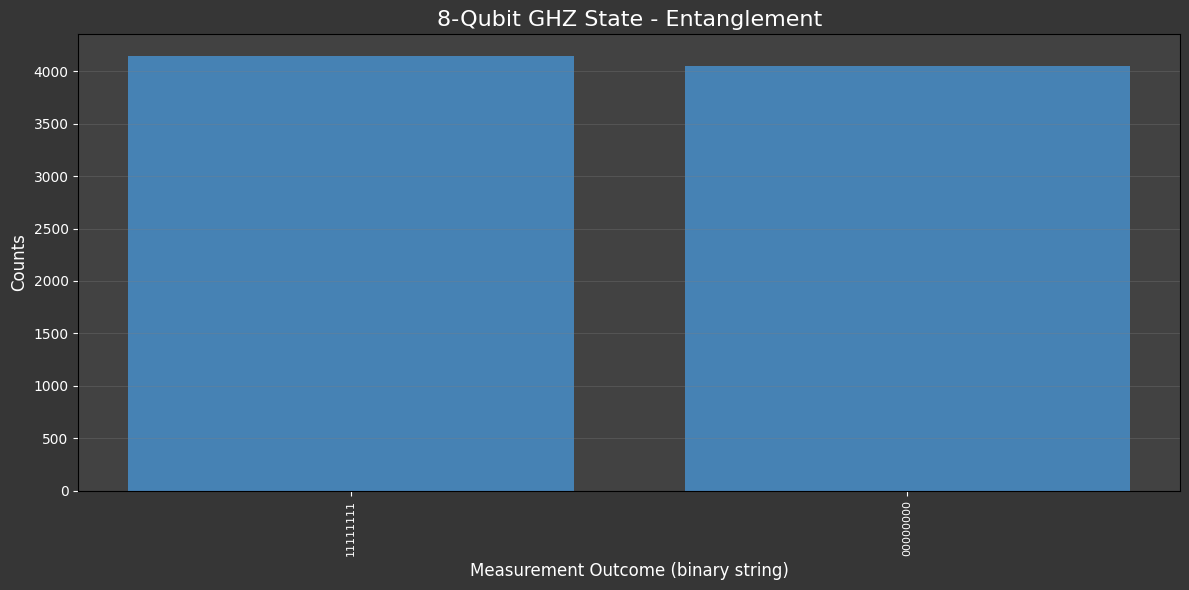

In [ ]:
print("=== Running da Vinci Quantum Emulator: 8-Qubit GHZ State ===")

ghz8_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[8];
creg c[8];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
"""

ghz8_results = run_qasm(ghz8_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz8_results.items())[:10]))

plot_results(ghz8_results, "8-Qubit GHZ State - Entanglement")

### 9-Qubit GHZ State Circuit

Following the pattern, the ideal 9-qubit GHZ state is (1/√2)(|000000000⟩ + |111111111⟩), demonstrating entanglement across nine qubits.

=== Running da Vinci Quantum Emulator: 9-Qubit GHZ State ===
GHZ State Results (top 10): {'000000000': 4101, '111111111': 4091}


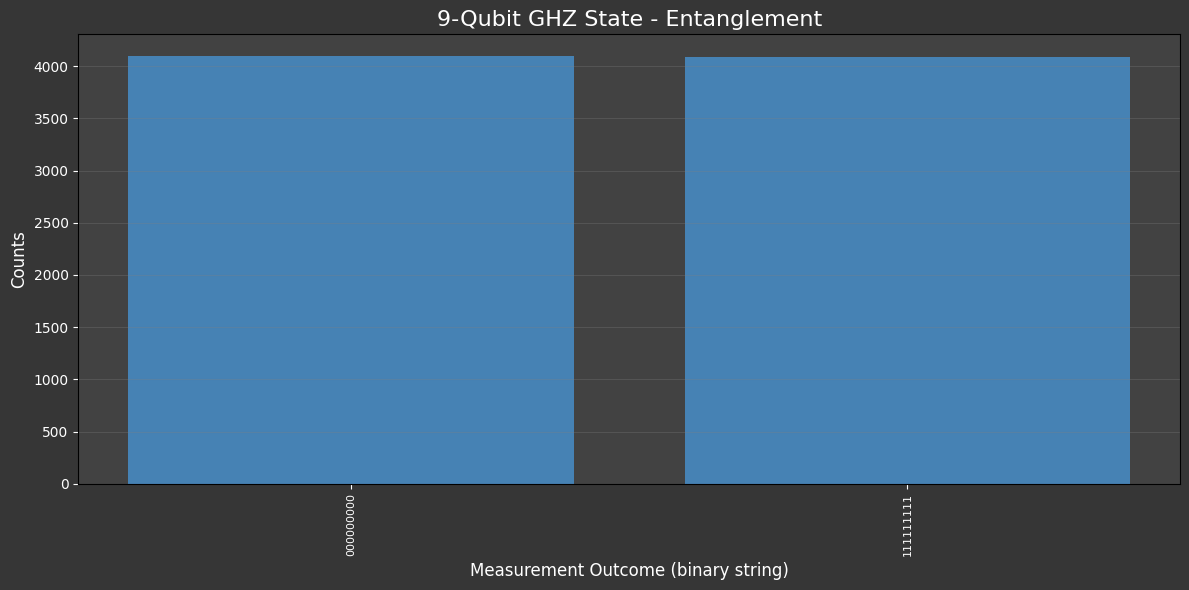

In [ ]:
print("=== Running da Vinci Quantum Emulator: 9-Qubit GHZ State ===")

ghz9_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[9];
creg c[9];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
"""

ghz9_results = run_qasm(ghz9_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz9_results.items())[:10]))

plot_results(ghz9_results, "9-Qubit GHZ State - Entanglement")

### 10-Qubit GHZ State Circuit

Extending to ten qubits, the ideal 10-qubit GHZ state is (1/√2)(|0000000000⟩ + |1111111111⟩), showcasing entanglement across ten qubits.

=== Running da Vinci Quantum Emulator: 10-Qubit GHZ State ===
GHZ State Results (top 10): {'1111111111': 4149, '0000000000': 4043}


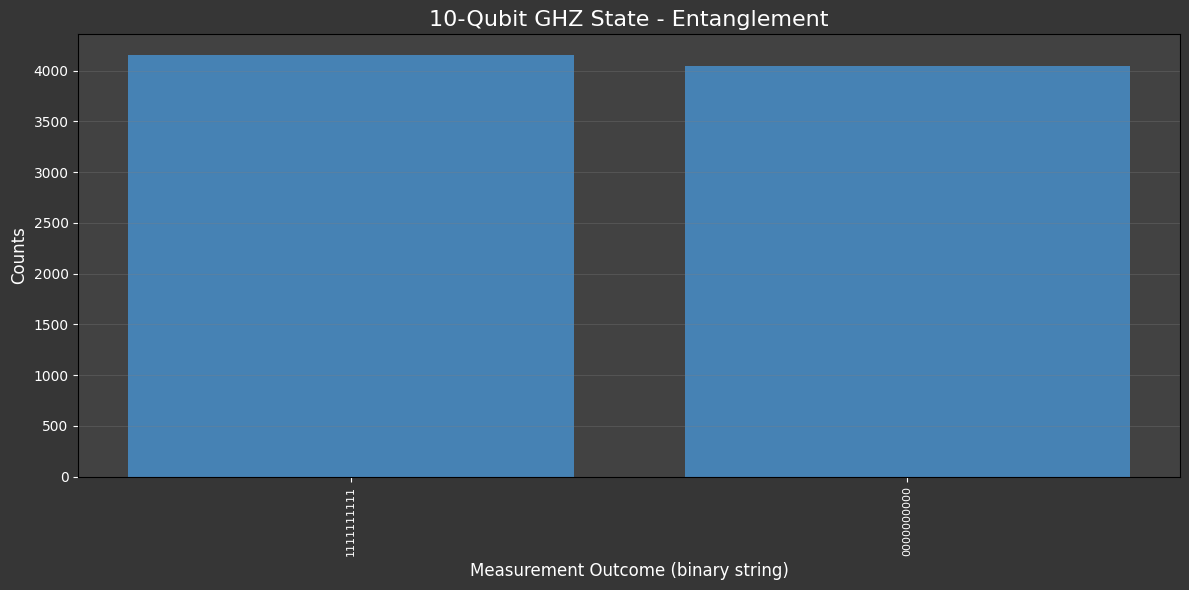

In [ ]:
print("=== Running da Vinci Quantum Emulator: 10-Qubit GHZ State ===")

ghz10_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[10];
creg c[10];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
"""

ghz10_results = run_qasm(ghz10_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz10_results.items())[:10]))

plot_results(ghz10_results, "10-Qubit GHZ State - Entanglement")

### 11-Qubit GHZ State Circuit

Continuing the expansion, the ideal 11-qubit GHZ state is (1/√2)(|00000000000⟩ + |11111111111⟩), showcasing entanglement across eleven qubits.

=== Running da Vinci Quantum Emulator: 11-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000000': 4052, '11111111111': 4140}


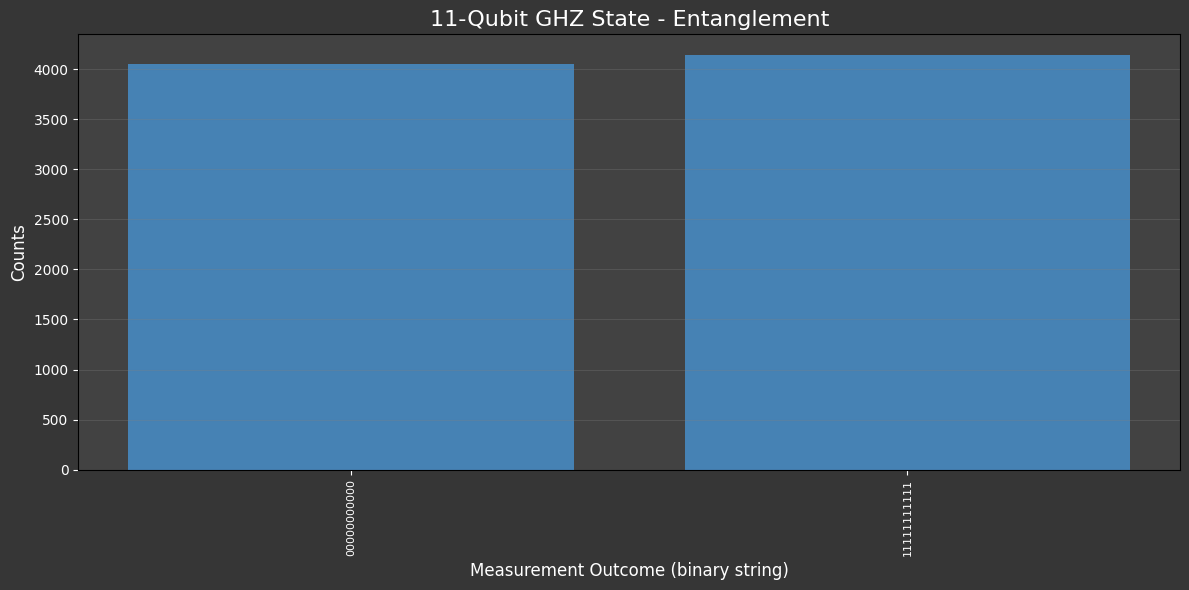

In [ ]:
print("=== Running da Vinci Quantum Emulator: 11-Qubit GHZ State ===")

ghz11_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[11];
creg c[11];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
"""

ghz11_results = run_qasm(ghz11_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz11_results.items())[:10]))

plot_results(ghz11_results, "11-Qubit GHZ State - Entanglement")

### 12-Qubit GHZ State Circuit

Extending to twelve qubits, the ideal 12-qubit GHZ state is (1/√2)(|000000000000⟩ + |111111111111⟩), showcasing entanglement across twelve qubits.

=== Running da Vinci Quantum Emulator: 12-Qubit GHZ State ===
GHZ State Results (top 10): {'111111111111': 4060, '000000000000': 4132}


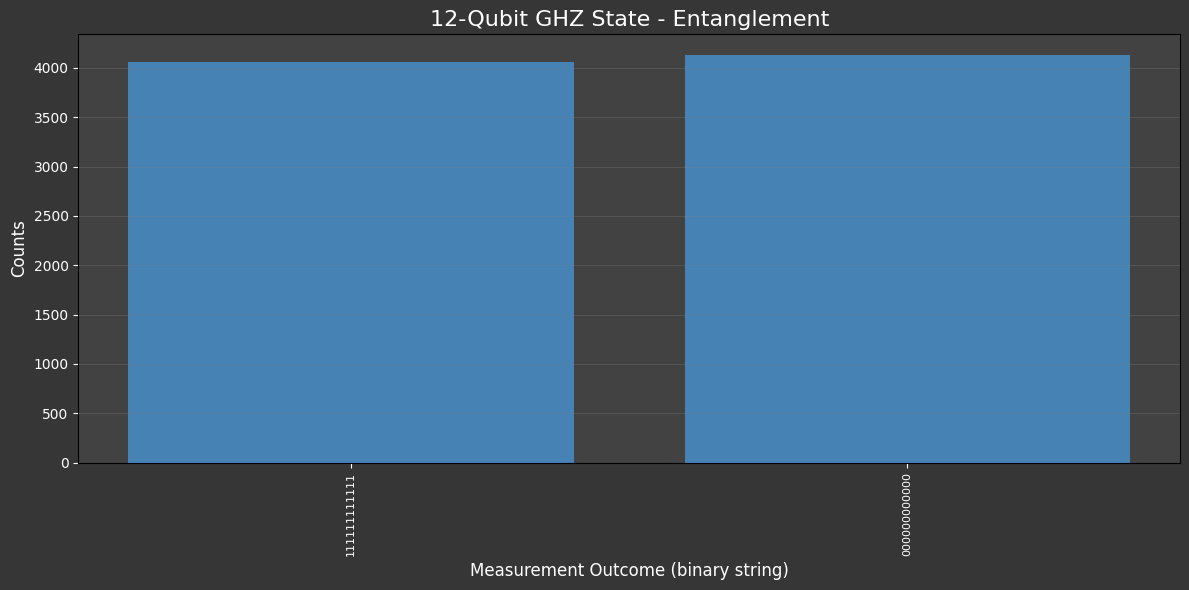

In [ ]:
print("=== Running da Vinci Quantum Emulator: 12-Qubit GHZ State ===")

ghz12_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[12];
creg c[12];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
"""

ghz12_results = run_qasm(ghz12_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz12_results.items())[:10]))

plot_results(ghz12_results, "12-Qubit GHZ State - Entanglement")

### 13-Qubit GHZ State Circuit

Extending to thirteen qubits, the ideal 13-qubit GHZ state is (1/√2)(|0000000000000⟩ + |1111111111111⟩), showcasing entanglement across thirteen qubits.

=== Running da Vinci Quantum Emulator: 13-Qubit GHZ State ===
GHZ State Results (top 10): {'1111111111111': 4101, '0000000000000': 4091}


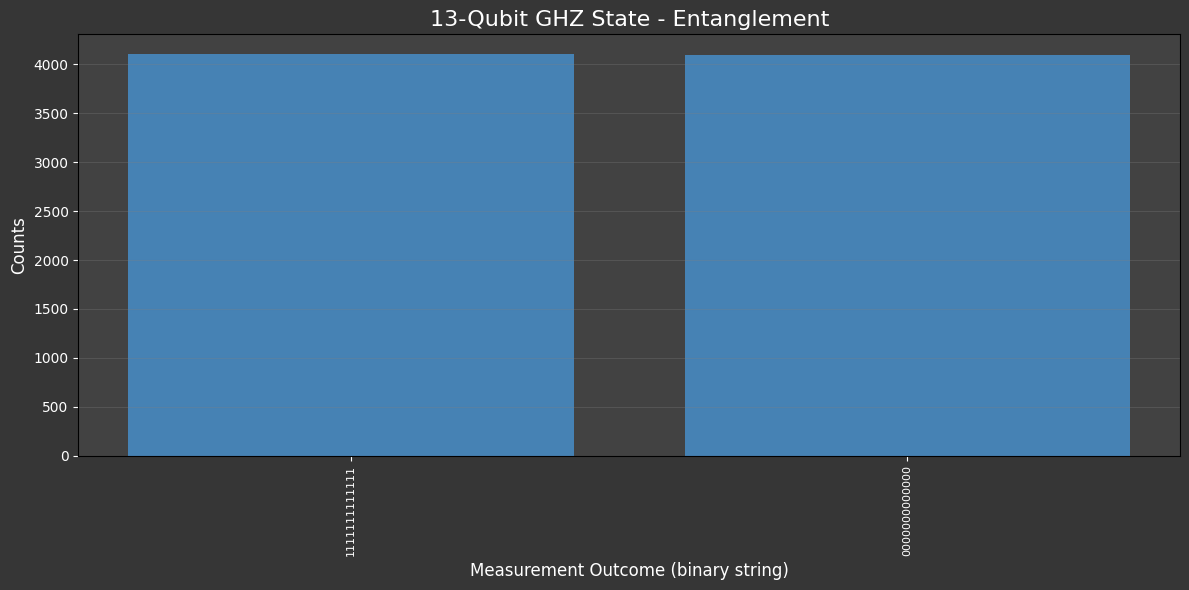

In [ ]:
print("=== Running da Vinci Quantum Emulator: 13-Qubit GHZ State ===")

ghz13_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[13];
creg c[13];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
"""

ghz13_results = run_qasm(ghz13_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz13_results.items())[:10]))

plot_results(ghz13_results, "13-Qubit GHZ State - Entanglement")

### 14-Qubit GHZ State Circuit

Continuing the expansion, the ideal 14-qubit GHZ state is (1/√2)(|00000000000000⟩ + |11111111111111⟩), showcasing entanglement across fourteen qubits.

=== Running da Vinci Quantum Emulator: 14-Qubit GHZ State ===
GHZ State Results (top 10): {'00000000000000': 4034, '11111111111111': 4158}


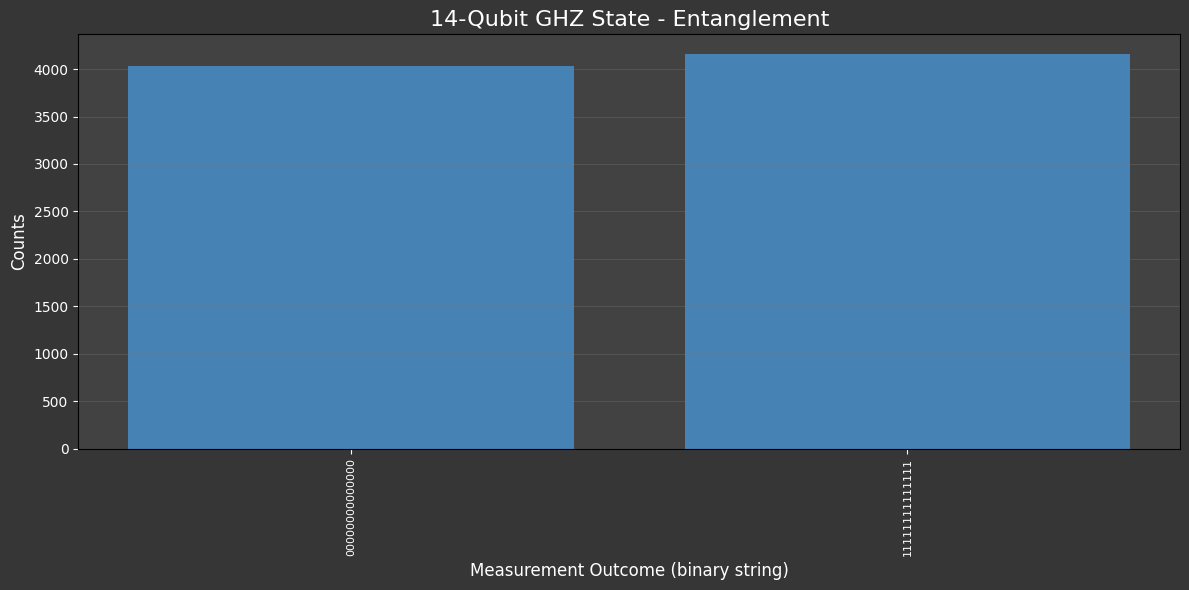

In [ ]:
print("=== Running da Vinci Quantum Emulator: 14-Qubit GHZ State ===")

ghz14_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[14];
creg c[14];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
"""

ghz14_results = run_qasm(ghz14_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz14_results.items())[:10]))

plot_results(ghz14_results, "14-Qubit GHZ State - Entanglement")

### 15-Qubit GHZ State Circuit

Continuing the expansion, the ideal 15-qubit GHZ state is (1/√2)(|000000000000000⟩ + |111111111111111⟩), showcasing entanglement across fifteen qubits.

=== Running da Vinci Quantum Emulator: 15-Qubit GHZ State ===
GHZ State Results (top 10): {'111111111111111': 4065, '000000000000000': 4127}


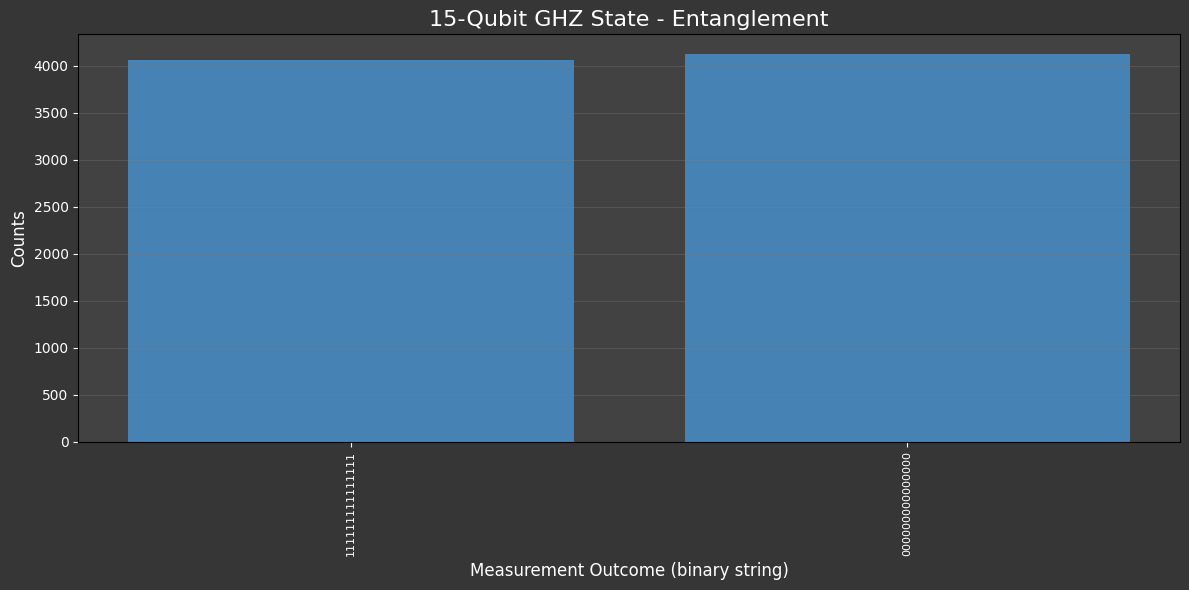

In [ ]:
print("=== Running da Vinci Quantum Emulator: 15-Qubit GHZ State ===")

ghz15_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[15];
creg c[15];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
"""

ghz15_results = run_qasm(ghz15_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz15_results.items())[:10]))

plot_results(ghz15_results, "15-Qubit GHZ State - Entanglement")

### 16-Qubit GHZ State Circuit

Extending to sixteen qubits, the ideal 16-qubit GHZ state is (1/√2)(|0000000000000000⟩ + |1111111111111111⟩), showcasing entanglement across sixteen qubits.

=== Running da Vinci Quantum Emulator: 16-Qubit GHZ State ===
GHZ State Results (top 10): {'1111111111111111': 4041, '0000000000000000': 4151}


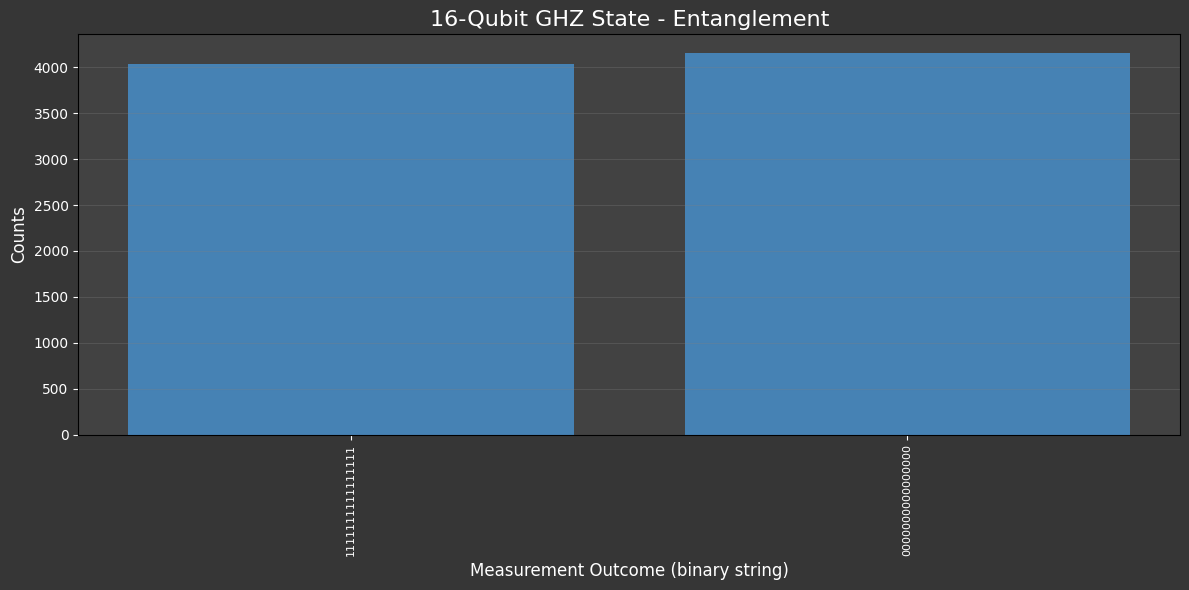

In [ ]:
print("=== Running da Vinci Quantum Emulator: 16-Qubit GHZ State ===")

ghz16_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[16];
creg c[16];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
"""

ghz16_results = run_qasm(ghz16_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz16_results.items())[:10]))

plot_results(ghz16_results, "16-Qubit GHZ State - Entanglement")

### 17-Qubit GHZ State Circuit

Extending to seventeen qubits, the ideal 17-qubit GHZ state is (1/√2)(|00000000000000000⟩ + |11111111111111111⟩), showcasing entanglement across seventeen qubits.

=== Running da Vinci Quantum Emulator: 17-Qubit GHZ State ===
GHZ State Results (top 10): {'11111111111111111': 1015, '00000000000000000': 1033}


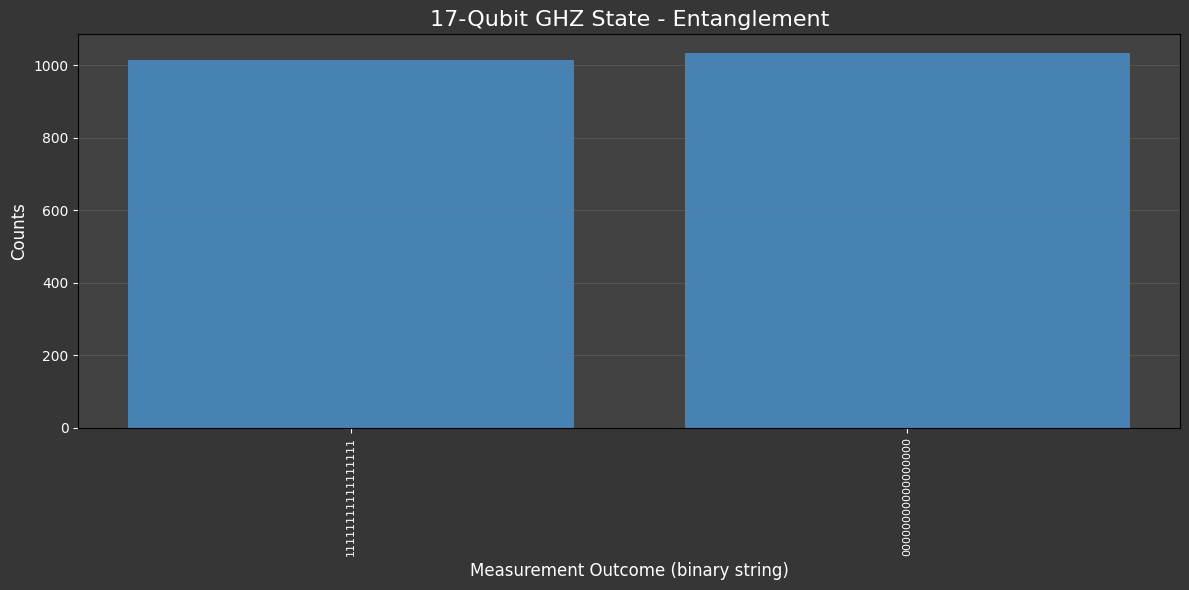

In [28]:
print("=== Running da Vinci Quantum Emulator: 17-Qubit GHZ State ===")

ghz17_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[17];
creg c[17];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target
cx q[0], q[16];  // CNOT with q[0] as control, q[16] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
"""

ghz17_results = run_qasm(ghz17_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz17_results.items())[:10]))

plot_results(ghz17_results, "17-Qubit GHZ State - Entanglement")

### 18-Qubit GHZ State Circuit

Extending to eighteen qubits, the ideal 18-qubit GHZ state is (1/√2)(|000000000000000000⟩ + |111111111111111111⟩), showcasing entanglement across eighteen qubits.

=== Running da Vinci Quantum Emulator: 18-Qubit GHZ State ===
GHZ State Results (top 10): {'000000000000000000': 1059, '111111111111111111': 989}


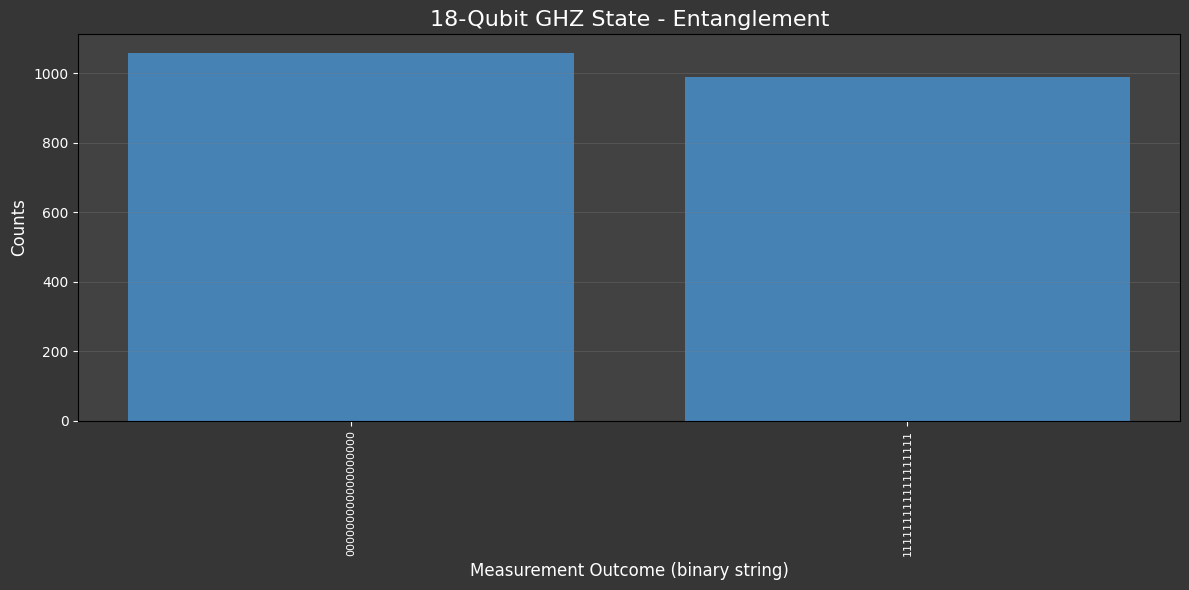

In [30]:
print("=== Running da Vinci Quantum Emulator: 18-Qubit GHZ State ===")

ghz18_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[18];
creg c[18];

h q[0];          // Apply Hadamard to the first qubit (q[0])
cx q[0], q[1];   // CNOT with q[0] as control, q[1] as target
cx q[0], q[2];   // CNOT with q[0] as control, q[2] as target
cx q[0], q[3];   // CNOT with q[0] as control, q[3] as target
cx q[0], q[4];   // CNOT with q[0] as control, q[4] as target
cx q[0], q[5];   // CNOT with q[0] as control, q[5] as target
cx q[0], q[6];   // CNOT with q[0] as control, q[6] as target
cx q[0], q[7];   // CNOT with q[0] as control, q[7] as target
cx q[0], q[8];   // CNOT with q[0] as control, q[8] as target
cx q[0], q[9];   // CNOT with q[0] as control, q[9] as target
cx q[0], q[10];  // CNOT with q[0] as control, q[10] as target
cx q[0], q[11];  // CNOT with q[0] as control, q[11] as target
cx q[0], q[12];  // CNOT with q[0] as control, q[12] as target
cx q[0], q[13];  // CNOT with q[0] as control, q[13] as target
cx q[0], q[14];  // CNOT with q[0] as control, q[14] as target
cx q[0], q[15];  // CNOT with q[0] as control, q[15] as target
cx q[0], q[16];  // CNOT with q[0] as control, q[16] as target
cx q[0], q[17];  // CNOT with q[0] as control, q[17] as target

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];
measure q[9] -> c[9];
measure q[10] -> c[10];
measure q[11] -> c[11];
measure q[12] -> c[12];
measure q[13] -> c[13];
measure q[14] -> c[14];
measure q[15] -> c[15];
measure q[16] -> c[16];
measure q[17] -> c[17];
"""

ghz18_results = run_qasm(ghz18_qasm, SHOTS)
print("GHZ State Results (top 10):", dict(list(ghz18_results.items())[:10]))

plot_results(ghz18_results, "18-Qubit GHZ State - Entanglement")